# Package Management

In [ ]:
pip install yfinance

In [9]:
import os
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf # API to download Financial Data

'''
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
'''

'\nfrom sklearn.preprocessing import StandardScaler\nfrom tensorflow.keras.models import Model\nfrom tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout\nfrom tensorflow.keras.optimizers import Adam\n'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data

In [13]:
stocks = ['NVDA','TSLA','RTX','GOOG','XOM','JPM','UNH']
w_indices = ['^GSPC','000001.SS','^N225','DAX','^NSEI','^FTSE','^FCHI']
forex = ['EURUSD=X','JPYUSD=X','GBPUSD=X','CHFUSD=X','AUDUSD=X']
commodities = ['GC=F','SI=F','CL=F','HG=F']
other = ['^VIX']

feature_tickers = w_indices + forex + commodities + other

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/COEP Mtech 27/AI/Datasets"

# Saurabh Directory Link
# DATA_DIR = "/content/drive/MyDrive/Colab/Datasets"

In [14]:
# Will create a function to download all the data from yfinance

def get_data(ticker):
  data = yf.Tickers(ticker).history(period='10y')
  data.to_csv(f'{ticker}.csv')

In [15]:
for i in stocks:
  get_data(i)

  '''
for i in w_indices:
  get_data(i)

for i in forex:
  get_data(i)

for i in commodities:
  get_data(i)

for i in other:
  get_data(i)

'''


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NVDA']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TSLA']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RTX']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['GOOG']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['XOM']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JPM']: YFRateLimitError('Too Many Requests. Rate limited

In [ ]:
#  df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/COEP Mtech 27/AI/Datasets/UNH.csv')
# df = pd.read_csv("/content/drive/MyDrive/Colab/Datasets/UNH.csv")

# df=pd.read_csv("UNH.csv")


In [ ]:
df['Stock Splits'].unique()

array(['UNH', nan, '0.0'], dtype=object)

In [ ]:
# Remove Capital Gains, Dividends, Stock Splits

In [ ]:
df=df.drop(['Stock Splits','Dividends'],axis=1)

In [ ]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,UNH,UNH,UNH,UNH,UNH
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-11-18,100.13038635253906,100.36950265061357,97.14141959574685,97.56841484671716,3319900
3,2015-11-19,94.47693634033203,97.10722779965563,93.60586917675258,93.75958767802287,15731900
4,2015-11-20,96.47529602050781,97.73066294434079,94.45133643765162,94.69899443419408,7059400
...,...,...,...,...,...,...
2511,2025-11-11,327.45001220703125,327.8599853515625,319.8800048828125,323.29998779296875,7157800
2512,2025-11-12,339.05999755859375,343.1700134277344,327.0799865722656,328.45001220703125,10403300
2513,2025-11-13,332.5199890136719,339.0299987792969,331.2900085449219,338.3500061035156,7788700
2514,2025-11-14,321.8599853515625,328.2099914550781,320.489990234375,326.95001220703125,8676500


In [ ]:
df.isnull().sum()

,0
Price,0
Close,1
High,1
Low,1
Open,1
Volume,1


In [ ]:
df.dropna(inplace=True)

# Code

In [ ]:
stocks = ['NVDA','TSLA','RTX','GOOG','XOM','JPM','UNH']
w_indices = ['^GSPC','000001.SS','^N225','DAX','^NSEI','^FTSE','^FCHI']
forex = ['EURUSD=X','JPYUSD=X','GBPUSD=X','CHFUSD=X','AUDUSD=X']
commodities = ['GC=F','SI=F','CL=F','HG=F']
other = ['^VIX']

feature_tickers = w_indices + forex + commodities + other

In [ ]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/COEP Mtech 27/AI/Datasets"

## Building Functions

In [ ]:
# Returns CSV with Date as Index and OHLCV Data

def load_single_ticker_csv(path):

    df = pd.read_csv(path)
    if 'Price' not in df.columns:
        raise ValueError(f"Unexpected columns in {path}: {df.columns}")

    # Real data starts at row 2
    data = df.iloc[2:].copy()
    data = data.rename(columns={'Price': 'Date'})
    data['Date'] = pd.to_datetime(data['Date'])
    data = data.set_index('Date')

    # Keep only OHLCV
    out = data[['Open', 'High', 'Low', 'Close', 'Volume']].astype(float)
    return out


In [ ]:
load_single_ticker_csv('/content/drive/MyDrive/Colab Notebooks/COEP Mtech 27/AI/Datasets/UNH.csv').head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-11-18,97.568415,100.369503,97.141420,100.130386,3319900.0
2015-11-19,93.759588,97.107228,93.605869,94.476936,15731900.0
2015-11-20,94.698994,97.730663,94.451336,96.475296,7059400.0
2015-11-23,96.475276,97.773339,95.732303,95.783546,3780400.0
2015-11-24,95.117428,96.885187,94.844151,96.663155,3244800.0


In [ ]:
# Built Feature and Stocks Centralized Dictionary

def load_ticker_panel(tickers, base_dir):

    panel = {}
    for t in tickers:
        fname = f"{t}.csv"
        path = os.path.join(base_dir, fname)
        if not os.path.exists(path):
            warnings.warn(f"File for {t} not found at {path}, skipping.")
            continue
        panel[t] = load_single_ticker_csv(path)
    return panel

stock_panel = load_ticker_panel(stocks, DATA_DIR)           # target assets
feat_panel  = load_ticker_panel(feature_tickers, DATA_DIR)  # feature assets

print("Loaded stocks:", list(stock_panel.keys()))
print("Loaded features:", list(feat_panel.keys()))

Loaded stocks: ['NVDA', 'TSLA', 'RTX', 'GOOG', 'XOM', 'JPM', 'UNH']
Loaded features: ['^GSPC', '000001.SS', '^N225', 'DAX', '^NSEI', '^FTSE', '^FCHI', 'EURUSD=X', 'JPYUSD=X', 'GBPUSD=X', 'CHFUSD=X', 'AUDUSD=X', 'GC=F', 'SI=F', 'CL=F', 'HG=F', '^VIX']


In [ ]:
stock_panel['TSLA'].tail()

,Open,High,Low,Close,Volume
Date,,,,,
2025-11-11,439.399994,442.489990,432.359985,439.619995,60533200.0
2025-11-12,442.149994,442.329987,426.559998,430.600006,58513500.0
2025-11-13,423.130005,424.500000,396.339996,401.989990,118948000.0
2025-11-14,386.299988,412.190002,382.779999,404.350006,105506700.0
2025-11-17,398.739990,423.959991,398.739990,408.920013,101741100.0


In [ ]:
feat_panel['^GSPC'].tail()

,Open,High,Low,Close,Volume
Date,,,,,
2025-11-11,6815.640137,6855.129883,6806.870117,6846.609863,4.983490e+09
2025-11-12,6867.770020,6869.910156,6829.620117,6850.919922,5.293610e+09
2025-11-13,6826.470215,6828.049805,6724.720215,6737.490234,5.473720e+09
2025-11-14,6672.140137,6774.310059,6646.870117,6734.109863,5.042660e+09
2025-11-17,6713.609863,6754.500000,6638.899902,6672.410156,5.204220e+09


In [ ]:
# Function to combine components to be used as Features on Date Intersections

def build_feature_matrix(panel):

    common_idx = None
    for t, df in panel.items():
        common_idx = df.index if common_idx is None else common_idx.intersection(df.index) # Only take the dates that are present in all the dataframes

    if common_idx is None:
        return pd.DataFrame()

    common_idx = common_idx.sort_values()
    frames = []
    for t, df in panel.items():  # Combining all the stocks at once
        sub = df.loc[common_idx]
        sub = sub.add_prefix(f"{t}_")
        frames.append(sub)

    X_df = pd.concat(frames, axis=1)
    return X_df

X_df = build_feature_matrix(feat_panel)
print("Feature matrix:", X_df.shape)

Feature matrix: (2074, 85)


In [ ]:
# Data after Transformation
X_df.tail()

,^GSPC_Open,^GSPC_High,^GSPC_Low,^GSPC_Close,^GSPC_Volume,000001.SS_Open,000001.SS_High,000001.SS_Low,000001.SS_Close,000001.SS_Volume,...,HG=F_Open,HG=F_High,HG=F_Low,HG=F_Close,HG=F_Volume,^VIX_Open,^VIX_High,^VIX_Low,^VIX_Close,^VIX_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-11,6815.640137,6855.129883,6806.870117,6846.609863,4.983490e+09,4023.876953,4024.938965,3991.516113,4002.758057,582000.0,...,5.0425,5.0485,5.0420,5.0485,685.0,17.900000,18.010000,17.250000,17.280001,0.0
2025-11-12,6867.770020,6869.910156,6829.620117,6850.919922,5.293610e+09,3996.564941,4020.376953,3980.676025,4000.139893,586200.0,...,5.0430,5.1270,5.0370,5.0895,656.0,17.209999,18.059999,17.100000,17.510000,0.0
2025-11-13,6826.470215,6828.049805,6724.720215,6737.490234,5.473720e+09,3996.513916,4030.397949,3994.770996,4029.500977,613000.0,...,5.0995,5.1040,5.0380,5.0875,795.0,17.610001,21.309999,17.510000,20.000000,0.0
2025-11-14,6672.140137,6774.310059,6646.870117,6734.109863,5.042660e+09,4007.125977,4034.079102,3990.306885,3990.491943,622000.0,...,5.0510,5.0510,5.0485,5.0495,780.0,21.330000,23.030001,19.559999,19.830000,0.0
2025-11-17,6713.609863,6754.500000,6638.899902,6672.410156,5.204220e+09,3988.555908,3992.404053,3958.947998,3972.034912,592000.0,...,4.9980,5.0025,4.9975,5.0000,780.0,19.580000,23.440001,19.540001,22.379999,0.0


In [ ]:
# Same as above for Stocks (Outputs)

def build_stock_close_matrix(panel):
    common_idx = None
    for t, df in panel.items():
        common_idx = df.index if common_idx is None else common_idx.intersection(df.index)

    if common_idx is None:
        return pd.DataFrame()

    common_idx = common_idx.sort_values()
    frames = []
    for t, df in panel.items():
        sub = df.loc[common_idx][['Close']].rename(columns={'Close': t})
        frames.append(sub)

    Y_close = pd.concat(frames, axis=1)
    return Y_close

Y_close = build_stock_close_matrix(stock_panel)
print("Stock close matrix:", Y_close.shape)

Stock close matrix: (2488, 7)


In [ ]:
Y_close.tail()

,NVDA,TSLA,RTX,GOOG,XOM,JPM,UNH
Date,,,,,,,
2025-11-11,193.149246,439.619995,179.220001,291.739990,118.741417,315.619995,327.450012
2025-11-12,193.789215,430.600006,177.690002,287.429993,117.095818,320.410004,339.059998
2025-11-13,186.849594,401.989990,173.960007,279.119995,117.760002,309.480011,332.519989
2025-11-14,190.159409,404.350006,175.570007,276.980011,119.290001,303.609985,321.859985
2025-11-17,186.589615,408.920013,175.630005,285.600006,117.680000,300.369995,320.519989


In [ ]:
def build_cnn_lstm_model(lookback, num_features, num_stocks):
    inp = Input(shape=(lookback, num_features)) # Samples, features

    # CNN part: local temporal patterns in macro/FX/commodity/VIX features
    x = Conv1D(filters=32, kernel_size=3, padding='causal', activation='relu')(inp) # Output = (lookback,num_features, 32)
    x = Conv1D(filters=64, kernel_size=3, padding='causal', activation='relu')(x)

    # LSTM part: longer-term temporal dependence
    x = LSTM(64, return_sequences=False)(x) # Output = (samples, 64)
    x = Dropout(0.2)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)

    # Output: predicted future returns for each stock
    out = Dense(num_stocks, activation='linear', name='return_pred')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse',metrics=['accuracy','mse'])
    return model



In [ ]:
# Computing weights of stocks using Softmax
# Lower Temp implies more concentrated Portfolio

def returns_to_weights(pred_returns, temperature=0.1):
    scaled = pred_returns / temperature
    exp_r = np.exp(scaled - np.max(scaled))  # numerical stability
    w = exp_r / exp_r.sum()
    return w

In [ ]:
# Returns Dataframe with weights per rebalance date. Rebalance dates are also
# tracked

def generate_weekly_allocations(
    model, X_seq, seq_dates,
    tickers, rebalance_weeks=1,temperature=0.1):

    step = rebalance_weeks * 5
    reb_dates = []
    reb_weights = []

    i = 0
    while i < len(X_seq):
        x = X_seq[i][np.newaxis, ...]  # (1, lookback, features)
        pred = model.predict(x, verbose=0)[0]  # (num_stocks,)
        w = returns_to_weights(pred, temperature=temperature)
        reb_dates.append(seq_dates[i])
        reb_weights.append(w)
        i += step

    alloc_df = pd.DataFrame(reb_weights, index=reb_dates, columns=tickers)
    return alloc_df



In [ ]:
# Track Allocation Changes using threshold

def allocation_change_signals(alloc_df, change_threshold=0.05):

    signals = []
    prev_w = None

    for date, w in alloc_df.iterrows():
        w_vec = w.values
        if prev_w is None:
            signals.append(1)  # first rebalance -> allocate
        else:
            l1_change = np.abs(w_vec - prev_w).sum()
            signals.append(1 if l1_change > change_threshold else 0)
        prev_w = w_vec

    signal_df = alloc_df.copy()
    signal_df['signal'] = signals
    return signal_df




In [ ]:
# Computes Daily, Cumulative Portfolio Returns

def compute_portfolio_returns(
    daily_weights,
    Y_close,
    daily_turnover=None,
    transaction_cost_bps=0.0
):
    """
    daily_weights > DataFrame [dates x tickers], weights per day
    Y_close > DataFrame [dates x tickers], close prices
    daily_turnover > Series [dates], from build_daily_weights; if None -> no cost
    transaction_cost_bps > float, cost per 1-way trade in basis points (bps).
                          Example: 10 bps = 0.10% per notional traded.

    Returns:
        port_daily_ret: Series of daily net returns (after costs)
        port_curve:     Series of cumulative portfolio value (starting at 1.0)
    """
    tickers = [c for c in daily_weights.columns if c in Y_close.columns]
    daily_ret = Y_close[tickers].pct_change().fillna(0)

    # Align
    daily_weights = daily_weights.reindex(daily_ret.index).fillna(method='ffill')

    # Gross portfolio returns
    gross_ret = (daily_weights * daily_ret).sum(axis=1)

    if daily_turnover is None:
        net_ret = gross_ret
    else:
        daily_turnover = daily_turnover.reindex(daily_ret.index).fillna(0)
        # cost per day = turnover * cost_rate
        cost_rate = transaction_cost_bps / 10000.0
        cost = daily_turnover * cost_rate
        net_ret = gross_ret - cost

    port_curve = (1 + net_ret).cumprod()

    return net_ret, port_curve


In [ ]:
# Builds Daily Weights for the stocks for allocation

def build_daily_weights(
    allocations_df,
    Y_close,
    signals_df=None,
    max_turnover=None
):
    """
    allocations_df: rebalance weights, index = rebalance dates, cols = tickers
    Y_close:        daily close prices, index = all trading dates, cols = tickers
    signals_df:     optional, same index as allocations_df with 'signal' col
    max_turnover:   optional, max allowed L1 change in weights per day (e.g. 0.5)
                    If None -> no cap.

    Returns:
        daily_weights: DataFrame [dates x tickers]
        daily_turnover: Series [dates] (L1 turnover / 2)
    """
    tickers = [c for c in allocations_df.columns if c in Y_close.columns]

    # Daily returns index
    daily_idx = Y_close.index

    # 1) Start from rebalance weights, ffill to daily
    raw_daily = allocations_df[tickers].reindex(daily_idx, method='ffill')

    # 2) Handle signals: if signal=0, keep previous weights (no new rebalance)
    if signals_df is not None and 'signal' in signals_df.columns:
        sig_daily = signals_df['signal'].reindex(daily_idx, method='ffill').fillna(0)

        adj = raw_daily.copy()
        for i in range(1, len(adj)):
            if sig_daily.iloc[i] == 0:
                # keep yesterday's weights
                adj.iloc[i] = adj.iloc[i-1]
        raw_daily = adj

    # 3) Apply turnover cap (if any)
    daily_weights = raw_daily.copy()
    daily_turnover = pd.Series(index=daily_idx, dtype=float)

    prev_w = None
    for i, (dt, w) in enumerate(daily_weights.iterrows()):
        w_vec = w.values.astype(float)

        if prev_w is None:
            # normalize first day, zero turnover
            if w_vec.sum() != 0:
                w_vec = w_vec / w_vec.sum()
            daily_weights.iloc[i] = w_vec
            daily_turnover.iloc[i] = 0.0
            prev_w = w_vec
            continue

        # target change
        delta = w_vec - prev_w
        l1_change = np.abs(delta).sum()

        # cap turnover if requested
        if (max_turnover is not None) and (l1_change > max_turnover) and (l1_change > 0):
            scale = max_turnover / l1_change
            w_vec = prev_w + scale * delta
            # re-normalize to sum 1
            if w_vec.sum() != 0:
                w_vec = w_vec / w_vec.sum()
            delta = w_vec - prev_w
            l1_change = np.abs(delta).sum()

        # store
        daily_weights.iloc[i] = w_vec
        # standard convention: turnover = 0.5 * L1 (buy+sell)
        daily_turnover.iloc[i] = 0.5 * l1_change
        prev_w = w_vec

    return daily_weights, daily_turnover


In [ ]:
# Compute Portfolio Drawdown

def compute_drawdown(port_curve):

    running_max = port_curve.cummax()
    drawdown = port_curve / running_max - 1.0
    max_dd = drawdown.min()
    return drawdown, max_dd

In [ ]:
# Computes Computation Stats (Volatility, Returns, Sharpe, etc)

def compute_stats(
    port_daily_ret,
    risk_free_rate=0.0,
    periods_per_year=252
):

    # Basic stats
    avg_ret = port_daily_ret.mean()
    vol = port_daily_ret.std()

    # Annualization
    ann_ret = (1 + avg_ret) ** periods_per_year - 1
    ann_vol = vol * np.sqrt(periods_per_year)

    # Sharpe
    rf_daily = (1 + risk_free_rate) ** (1/periods_per_year) - 1
    excess_daily = port_daily_ret - rf_daily
    excess_ann_ret = (1 + excess_daily.mean()) ** periods_per_year - 1
    sharpe = excess_ann_ret / ann_vol if ann_vol > 0 else np.nan

    # Sortino
    downside = port_daily_ret[port_daily_ret < 0]
    downside_vol = downside.std()
    sortino = excess_ann_ret / (downside_vol * np.sqrt(periods_per_year)) if downside_vol > 0 else np.nan

    return {
        "avg_daily_ret": avg_ret,
        "daily_vol": vol,
        "ann_ret": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "sortino": sortino
    }


In [ ]:
# Built a function to build Backtest Report

def backtest_report(
    port_daily_ret,
    port_curve,
    risk_free_rate=0.0,
    periods_per_year=252
):
    drawdown, max_dd = compute_drawdown(port_curve)
    stats = compute_stats(port_daily_ret, risk_free_rate, periods_per_year)

    cagr = stats["ann_ret"]
    ann_vol = stats["ann_vol"]
    sharpe = stats["sharpe"]
    sortino = stats["sortino"]

    calmar = -cagr / max_dd if max_dd < 0 else np.nan

    report = {
        "CAGR": cagr,
        "Ann Vol": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
        "Final Value": port_curve.iloc[-1],
        "Start Date": port_curve.index[0],
        "End Date": port_curve.index[-1]
    }

    return report, drawdown


In [ ]:
# Forward Testing returning daily pf returns, cumulative value, allocations

def walk_forward_backtest(
    X_seq,
    y_seq,
    seq_dates,
    Y_close,
    tickers,
    train_window=1000,
    test_window=250,
    rebalance_weeks=1,
    temperature=0.1,
    max_turnover=None,
    transaction_cost_bps=0.0,
    epochs_per_step=5,
    batch_size=64
):
    """
    Returns:
        wf_port_ret:   Series of daily portfolio returns (net of costs)
        wf_port_curve: Series of cumulative value
        wf_allocations: dict with step -> allocations_df (rebalance-level)
    """
    num_samples = len(X_seq)
    start = train_window
    wf_port_ret_list = []
    wf_allocations = {}

    while start < num_samples - test_window:
        end_train = start
        end_test = min(start + test_window, num_samples)

        # Train slice
        X_tr = X_seq[end_train - train_window:end_train]
        y_tr = y_seq[end_train - train_window:end_train]

        # Corresponding dates for train/test slice
        dates_tr = seq_dates[end_train - train_window:end_train]
        dates_te = seq_dates[end_train:end_test]

        # Build & train model
        model = build_cnn_lstm_model(
            lookback=X_seq.shape[1],
            num_features=X_seq.shape[2],
            num_stocks=y_seq.shape[1]
        )

        model.fit(
            X_tr, y_tr,
            epochs=epochs_per_step,
            batch_size=batch_size,
            verbose=0
        )

        # Generate allocations on the test slice
        X_te = X_seq[end_train:end_test]
        alloc_df = generate_weekly_allocations(
            model,
            X_te,
            dates_te,        # IMPORTANT: use dates of that slice
            tickers=tickers,
            rebalance_weeks=rebalance_weeks,
            temperature=temperature
        )

        wf_allocations[f"step_{start}"] = alloc_df

        # Signals
        signals_df = allocation_change_signals(
            alloc_df,
            change_threshold=0.1
        )

        # Daily weights + turnover
        daily_weights, daily_turnover = build_daily_weights(
            alloc_df,
            Y_close,
            signals_df=signals_df,
            max_turnover=max_turnover
        )

        # Restrict prices to the horizon we’re testing
        # (intersection of this test window’s dates with Y_close index)
        test_idx = pd.Index(dates_te)
        test_idx = test_idx.intersection(Y_close.index)

        dw_slice = daily_weights.loc[test_idx]
        dt_slice = daily_turnover.loc[test_idx]
        prices_slice = Y_close.loc[test_idx]

        # Portfolio returns for this step
        step_ret, step_curve = compute_portfolio_returns(
            dw_slice,
            prices_slice,
            daily_turnover=dt_slice,
            transaction_cost_bps=transaction_cost_bps
        )

        wf_port_ret_list.append(step_ret)

        # Move forward
        start += test_window

    # Stitch all steps
    wf_port_ret = pd.concat(wf_port_ret_list).sort_index()
    wf_port_curve = (1 + wf_port_ret).cumprod()

    return wf_port_ret, wf_port_curve, wf_allocations


In [ ]:
# Compare model performance with equal weight stocks

def compare_with_equal_weight(
    model_port_ret,
    model_port_curve,
    Y_close,
    tickers,
    risk_free_rate=0.0
):

    # --- Equal-Weight Portfolio (EW) ---
    ew_w = np.array([1/len(tickers)] * len(tickers))
    daily_ret = Y_close[tickers].pct_change().fillna(0)

    ew_ret = (daily_ret * ew_w).sum(axis=1)
    ew_curve = (1 + ew_ret).cumprod()

    # --- Compute stats ---
    model_report, model_dd = backtest_report(model_port_ret, model_port_curve, risk_free_rate)
    ew_report, ew_dd = backtest_report(ew_ret, ew_curve, risk_free_rate)

    comparison = pd.DataFrame({
        "Model": model_report,
        "EqualWeight": ew_report
    })

    return comparison, ew_ret, ew_curve


## Data Preparation

In [ ]:
LOOKBACK_DAYS = 60     # input window length
PRED_HORIZON = 5       # predict 5 trading days ahead (~1 week)
REB_WEEKS = 1          # rebalance every 1 week (hyper-param)
TEST_SPLIT = 0.2
BATCH_SIZE = 64
EPOCHS = 30

In [ ]:
common_index = X_df.index.intersection(Y_close.index).sort_values()
X_df = X_df.loc[common_index]
Y_close = Y_close.loc[common_index]

print("Aligned shapes:", X_df.shape, Y_close.shape)

Aligned shapes: (2051, 85) (2051, 7)


In [ ]:
# Future close shifted by -PRED_HORIZON
Y_future = Y_close.shift(-PRED_HORIZON)

# Future returns
# Y_ret = (Y_future - Y_close) / Y_close
Y_ret = np.log((Y_future + 1)/(Y_close + 1))

# Drop last PRED_HORIZON rows where future is NaN
mask_valid = ~Y_ret.isna().any(axis=1)
X_df = X_df.loc[mask_valid]
Y_ret = Y_ret.loc[mask_valid]

print("After horizon alignment:", X_df.shape, Y_ret.shape)

After horizon alignment: (2046, 85) (2046, 7)


In [ ]:
X_df.tail()

,^GSPC_Open,^GSPC_High,^GSPC_Low,^GSPC_Close,^GSPC_Volume,000001.SS_Open,000001.SS_High,000001.SS_Low,000001.SS_Close,000001.SS_Volume,...,HG=F_Open,HG=F_High,HG=F_Low,HG=F_Close,HG=F_Volume,^VIX_Open,^VIX_High,^VIX_Low,^VIX_Close,^VIX_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-31,6879.169922,6879.169922,6814.259766,6840.200195,6.398280e+09,3985.063965,3986.742920,3951.730957,3954.790039,675600.0,...,5.0785,5.0995,5.0615,5.0655,982.0,16.430000,18.540001,15.960000,17.440001,0.0
2025-11-04,6788.520020,6820.209961,6766.709961,6771.549805,5.739510e+09,3973.458008,3985.882080,3938.520020,3960.186035,615500.0,...,4.9195,4.9390,4.9195,4.9260,590.0,19.730000,20.480000,17.900000,19.000000,0.0
2025-11-06,6787.589844,6796.680176,6707.509766,6720.319824,6.051900e+09,3973.349121,4008.799072,3973.349121,4007.760010,627400.0,...,4.9625,4.9630,4.9365,4.9455,946.0,18.360001,20.309999,17.639999,19.500000,0.0
2025-11-07,6696.180176,6730.109863,6631.439941,6728.799805,5.926070e+09,3994.316895,4012.004883,3993.690918,3997.555908,596500.0,...,4.9445,4.9450,4.9355,4.9380,599.0,19.520000,22.719999,19.080000,19.080000,0.0
2025-11-10,6785.359863,6841.319824,6770.560059,6832.430176,5.366050e+09,4001.793945,4018.696045,3990.835938,4018.596924,634000.0,...,5.0160,5.0895,5.0160,5.0870,1048.0,18.580000,18.820000,17.600000,17.600000,0.0


In [ ]:
Y_ret.tail()

,NVDA,TSLA,RTX,GOOG,XOM,JPM,UNH
Date,,,,,,,
2025-10-31,-0.046934,-0.037725,0.004003,0.034474,0.045910,0.014315,-0.042062
2025-11-04,-0.024793,-0.031159,0.011709,0.033026,0.033980,0.035339,0.024499
2025-11-06,-0.006473,-0.103446,-0.006495,-0.021962,0.036467,-0.012610,0.033414
2025-11-07,0.010623,-0.060243,-0.007898,-0.009737,0.025993,-0.034207,-0.007252
2025-11-10,-0.064255,-0.084872,-0.019066,-0.017261,0.004095,-0.053367,-0.003291


### Scaling and Splitting

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df.values)

num_features = X_scaled.shape[1]
tickers_in_use = list(Y_ret.columns)    # may be subset of stocks if some CSVs missing
num_stocks = len(tickers_in_use)

def create_sequences(X, y, lookback):
    X_seq, y_seq, dates = [], [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
        dates.append(X_df.index[i])
    return np.array(X_seq), np.array(y_seq), np.array(dates)

X_seq, y_seq, seq_dates = create_sequences(X_scaled, Y_ret.values, LOOKBACK_DAYS)
print("Sequences:", X_seq.shape, y_seq.shape)

Sequences: (1986, 60, 85) (1986, 7)


In [ ]:
split_idx = int((1 - TEST_SPLIT) * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
dates_train, dates_test = seq_dates[:split_idx], seq_dates[split_idx:]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1588, 60, 85) Test: (398, 60, 85)


## Model Building

In [ ]:
model = build_cnn_lstm_model(LOOKBACK_DAYS, num_features, num_stocks)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 85)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 32)         │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ return_pred (Dense)             │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,039 (203.28 KB)

 Trainable params: 52,039 (203.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.1537 - loss: 0.0160 - mse: 0.0160 - val_accuracy: 0.2035 - val_loss: 0.0053 - val_mse: 0.0053
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.2128 - loss: 0.0039 - mse: 0.0039 - val_accuracy: 0.2513 - val_loss: 0.0040 - val_mse: 0.0040
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.2083 - loss: 0.0029 - mse: 0.0029 - val_accuracy: 0.2412 - val_loss: 0.0039 - val_mse: 0.0039
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.2461 - loss: 0.0030 - mse: 0.0030 - val_accuracy: 0.2387 - val_loss: 0.0038 - val_mse: 0.0038
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.2436 - loss: 0.0030 - mse: 0.0030 - val_accuracy: 0.2538 - val_loss: 0.0039 - val_mse: 0.0039
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.2373 - loss: 0.0029 - mse: 0.0029 - val_accuracy: 0.2915 - val_loss: 0.0040 - val_mse: 0.0040
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 87m

In [ ]:
model.evaluate(X_test, y_test, verbose=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2202 - loss: 0.0070 - mse: 0.0070


[0.00938475877046585, 0.2135678380727768, 0.00938475877046585]

## Computing Predictions

In [ ]:
allocations_df = generate_weekly_allocations(
    model,
    X_seq,
    seq_dates,
    tickers=tickers_in_use,     # only those with CSVs
    rebalance_weeks=REB_WEEKS,
    temperature=0.1
)

print(allocations_df.tail())

                NVDA      TSLA       RTX      GOOG       XOM       JPM  \
2025-09-29  0.216207  0.236889  0.089146  0.154162  0.062790  0.150668   
2025-10-15  0.215570  0.192738  0.094541  0.172055  0.068224  0.169487   
2025-10-23  0.237091  0.176780  0.099471  0.173133  0.071706  0.160168   
2025-10-30  0.209547  0.189580  0.094098  0.175650  0.071701  0.155572   
2025-11-10  0.213603  0.201792  0.090787  0.137614  0.070981  0.180413   

                 UNH  
2025-09-29  0.090138  
2025-10-15  0.087385  
2025-10-23  0.081652  
2025-10-30  0.103852  
2025-11-10  0.104809  


In [ ]:
signal_df = allocation_change_signals(allocations_df, change_threshold=0.1)
print(signal_df.tail())

                NVDA      TSLA       RTX      GOOG       XOM       JPM  \
2025-09-29  0.216207  0.236889  0.089146  0.154162  0.062790  0.150668   
2025-10-15  0.215570  0.192738  0.094541  0.172055  0.068224  0.169487   
2025-10-23  0.237091  0.176780  0.099471  0.173133  0.071706  0.160168   
2025-10-30  0.209547  0.189580  0.094098  0.175650  0.071701  0.155572   
2025-11-10  0.213603  0.201792  0.090787  0.137614  0.070981  0.180413   

                 UNH  signal  
2025-09-29  0.090138       0  
2025-10-15  0.087385       0  
2025-10-23  0.081652       0  
2025-10-30  0.103852       0  
2025-11-10  0.104809       0  


In [ ]:
port_ret, port_curve = compute_portfolio_returns(allocations_df, Y_close)
print(port_curve.tail())

Date
2025-11-11    70.060226
2025-11-12    70.006263
2025-11-13    67.576037
2025-11-14    67.501286
2025-11-17    67.451667
dtype: float64


In [ ]:
signals_df = allocation_change_signals(allocations_df, change_threshold=0.1)

daily_weights, daily_turnover = build_daily_weights(
    allocations_df,
    Y_close,
    signals_df=signals_df,
    max_turnover=0.5   # e.g. L1 change capped at 50% of the book per day
)

In [ ]:
signals_df = allocation_change_signals(allocations_df, change_threshold=0.1)

port_ret, port_curve = compute_portfolio_returns(
    allocations_df,
    Y_close,
)

print(port_curve.tail())

Date
2025-11-11    70.060226
2025-11-12    70.006263
2025-11-13    67.576037
2025-11-14    67.501286
2025-11-17    67.451667
dtype: float64


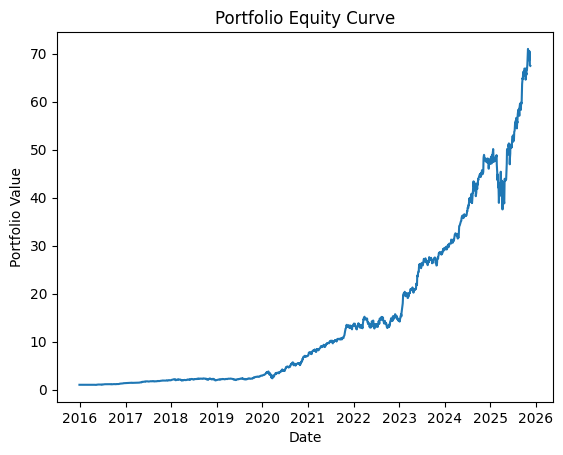

In [ ]:
plt.plot(port_curve)
plt.title("Portfolio Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.show()


In [ ]:
net_ret, port_curve = compute_portfolio_returns(
    daily_weights,
    Y_close,
    daily_turnover=daily_turnover,
    transaction_cost_bps=10  # 10 bps per turnover
)

In [ ]:
report, dd_series = backtest_report(net_ret, port_curve, risk_free_rate=0.02)

print('BackTest Report')
print()
for k, v in report.items():
    print(f"{k:15s}: {v}")

BackTest Report

CAGR           : 0.7191625252195175
Ann Vol        : 0.27508887777546137
Sharpe         : 2.4920038048395323
Sortino        : 3.246377051540861
Max Drawdown   : -0.37571019718044374
Calmar         : 1.9141416193027165
Final Value    : 60.55689806444457
Start Date     : 2015-12-29 00:00:00
End Date       : 2025-11-17 00:00:00


In [ ]:
wf_ret, wf_curve, wf_allocs = walk_forward_backtest(
    X_seq,
    y_seq,
    seq_dates,
    Y_close,
    tickers=tickers_in_use,
    train_window=1000,
    test_window=250,
    rebalance_weeks=REB_WEEKS,
    temperature=0.1,
    max_turnover=0.5,
    transaction_cost_bps=10,
    epochs_per_step=5
)

wf_report, wf_dd = backtest_report(wf_ret, wf_curve, risk_free_rate=0.02)

for k, v in wf_report.items():
    print(f"{k:15s}: {v}")

CAGR           : 0.4098693597637575
Ann Vol        : 0.23780667050441617
Sharpe         : 1.6074401947194084
Sortino        : 2.5928582804317855
Max Drawdown   : -0.2215471415850595
Calmar         : 1.8500322632526254
Final Value    : 2.556339765869751
Start Date     : 2021-02-02 00:00:00
End Date       : 2024-09-11 00:00:00


In [ ]:
comparison, ew_ret, ew_curve = compare_with_equal_weight(
    model_port_ret=net_ret,
    model_port_curve=port_curve,
    Y_close=Y_close,
    tickers=tickers_in_use,
    risk_free_rate=0.02
)

print('Model Performance Comparison with Equal Weight Portfolio Split')
print()
print(comparison)

Model Performance Comparison with Equal Weight Portfolio Split

                            Model          EqualWeight
CAGR                     0.719163             0.432247
Ann Vol                  0.275089              0.25313
Sharpe                   2.492004             1.596811
Sortino                  3.246377              1.98739
Max Drawdown             -0.37571            -0.416728
Calmar                   1.914142              1.03724
Final Value             60.556898            14.327676
Start Date    2015-12-29 00:00:00  2015-12-29 00:00:00
End Date      2025-11-17 00:00:00  2025-11-17 00:00:00


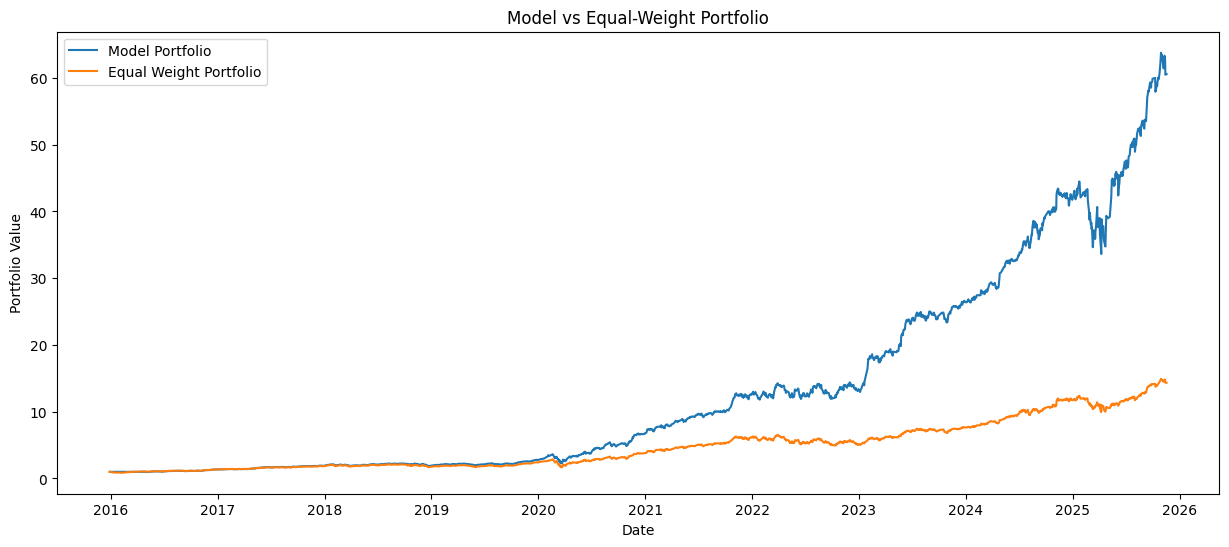

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(port_curve, label='Model Portfolio')
plt.plot(ew_curve, label='Equal Weight Portfolio')

plt.title('Model vs Equal-Weight Portfolio')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()

In [ ]:
# Save weights
model.save_weights(f'/content/drive/MyDrive/Colab Notebooks/COEP Mtech 27/AI/{datetime.datetime.now().strftime("%d-%m-%y")}_model.weights.h5')

# model.load_weights("model.weights.h5")


# Rough

In [ ]:
def compute_portfolio_returns(
    daily_weights,
    Y_close,
    daily_turnover=None,
    transaction_cost_bps=0.0
):
    """
    daily_weights:   DataFrame [dates x tickers], weights per day
    Y_close:         DataFrame [dates x tickers], close prices
    daily_turnover:  Series [dates], from build_daily_weights; if None -> no cost
    transaction_cost_bps: float, cost per 1-way trade in basis points (bps).
                          Example: 10 bps = 0.10% per notional traded.

    Returns:
        port_daily_ret: Series of daily net returns (after costs)
        port_curve:     Series of cumulative portfolio value (starting at 1.0)
    """
    tickers = [c for c in daily_weights.columns if c in Y_close.columns]
    daily_ret = Y_close[tickers].pct_change().fillna(0)

    # Align
    daily_weights = daily_weights.reindex(daily_ret.index).fillna(method='ffill')

    # Gross portfolio returns
    gross_ret = (daily_weights * daily_ret).sum(axis=1)

    if daily_turnover is None:
        net_ret = gross_ret
    else:
        daily_turnover = daily_turnover.reindex(daily_ret.index).fillna(0)
        # cost per day = turnover * cost_rate
        cost_rate = transaction_cost_bps / 10000.0
        cost = daily_turnover * cost_rate
        net_ret = gross_ret - cost

    port_curve = (1 + net_ret).cumprod()

    return net_ret, port_curve